## MobileNetV2 Implementation

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.utils import plot_model #for model visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from termcolor import colored
import cv2
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

In [2]:
with_mask_data = os.listdir(r'C:\Users\jackb\facemask\archive (13)\data\with_mask')

In [3]:
print(with_mask_data[0:5])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']


In [4]:
print('Number of with mask images:', len(with_mask_data))

Number of with mask images: 3725


In [5]:
without_mask_data = os.listdir(r'C:\Users\jackb\facemask\archive (13)\data\without_mask')

In [6]:
print(without_mask_data[0:5])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']


In [7]:
print('Number of without mask images:', len(without_mask_data))

Number of without mask images: 3828


In [8]:
with_mask_labels = [1]*len(with_mask_data)
print(f"With Mask labels" ,with_mask_labels[0:10])

without_mask_labels = [0]*len(without_mask_data)
print(f"Without Mask Labels", without_mask_labels[0:10])

With Mask labels [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Without Mask Labels [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [9]:
Labels = with_mask_labels + without_mask_labels
print(f"Labels", Labels[0:10])
print(f"Labels", Labels[-10:])

Labels [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Labels [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


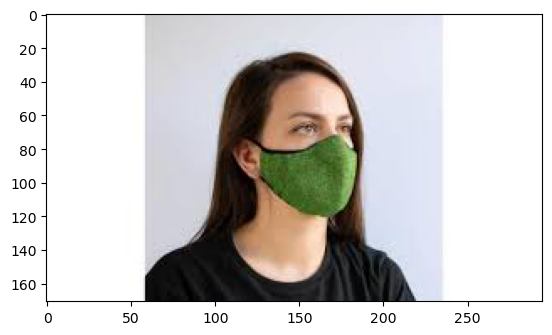

In [10]:
#display any image from with_mask_data randomly
import random
random_image = random.choice(with_mask_data)
img = Image.open('archive (13)/data/with_mask' + '/' + random_image)
plt.imshow(img)


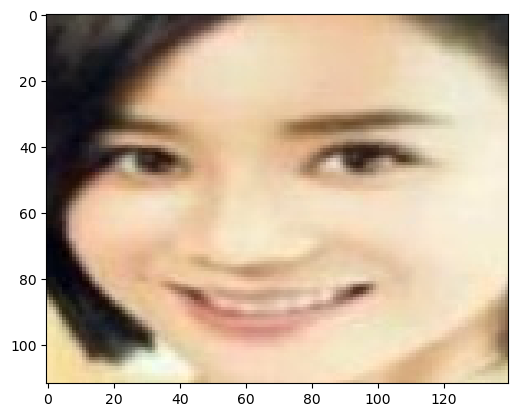

In [11]:
#display any image from without_mask_data randomly
import random
random_image = random.choice(without_mask_data)
img = Image.open(r'archive (13)/data/without_mask' + '/' + random_image)
plt.imshow(img)


In [12]:
#resize images and convert to numpy array


images = []
def load_images_from_folder(folder):
    
    for filename in os.listdir(folder):
        img = Image.open(os.path.join(folder,filename))
        img = img.resize((128,128))
        img = img.convert('RGB')
        images.append(np.array(img))
    return images

with_mask_images = load_images_from_folder(r'archive (13)/data/with_mask')
without_mask_images = load_images_from_folder(r'archive (13)/data/without_mask')

In [13]:
type(images)

list

In [14]:
images[0]

array([[[50, 58, 31],
        [46, 54, 34],
        [56, 59, 42],
        ...,
        [26, 32, 25],
        [29, 33, 18],
        [34, 40, 16]],

       [[47, 55, 30],
        [49, 57, 37],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [38, 42, 31],
        [31, 41, 22]],

       [[52, 58, 37],
        [50, 59, 38],
        [59, 64, 36],
        ...,
        [45, 44, 30],
        [29, 35, 28],
        [20, 30, 17]],

       ...,

       [[63, 72, 37],
        [66, 76, 41],
        [74, 84, 50],
        ...,
        [ 5,  4,  0],
        [20, 19, 15],
        [17, 17, 12]],

       [[59, 71, 34],
        [60, 70, 39],
        [68, 76, 50],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 29],
        [54, 64, 37],
        [57, 63, 43],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [20, 12, 13]]], dtype=uint8)

In [15]:
len(images)

7553

In [16]:
images[0].shape

(128, 128, 3)

In [17]:
type(images)

list

In [18]:
type(Labels)

list

In [19]:
X = np.array(images)
Y = np.array(Labels)

In [20]:
type(X)

numpy.ndarray

In [21]:
print(X.shape)

(7553, 128, 128, 3)


In [22]:
X[0]

array([[[50, 58, 31],
        [46, 54, 34],
        [56, 59, 42],
        ...,
        [26, 32, 25],
        [29, 33, 18],
        [34, 40, 16]],

       [[47, 55, 30],
        [49, 57, 37],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [38, 42, 31],
        [31, 41, 22]],

       [[52, 58, 37],
        [50, 59, 38],
        [59, 64, 36],
        ...,
        [45, 44, 30],
        [29, 35, 28],
        [20, 30, 17]],

       ...,

       [[63, 72, 37],
        [66, 76, 41],
        [74, 84, 50],
        ...,
        [ 5,  4,  0],
        [20, 19, 15],
        [17, 17, 12]],

       [[59, 71, 34],
        [60, 70, 39],
        [68, 76, 50],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 29],
        [54, 64, 37],
        [57, 63, 43],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [20, 12, 13]]], dtype=uint8)

In [23]:
type(Y)

numpy.ndarray

In [24]:
print(Y.shape)

(7553,)


In [25]:
Y

array([1, 1, 1, ..., 0, 0, 0])

In [26]:
#split the data into training and testing

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [27]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of Y_train is: {Y_train.shape}\n")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of Y_test is: {Y_test.shape}")

Shape of X_train is: (6042, 128, 128, 3)
Shape of Y_train is: (6042,)

Shape of X_test is: (1511, 128, 128, 3)
Shape of Y_test is: (1511,)


In [28]:
#scaling the data
X_train = X_train/255
X_test = X_test/255

print(X_train.shape)
print(X_test.shape)

(6042, 128, 128, 3)
(1511, 128, 128, 3)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten ,Dense ,Dropout ,BatchNormalization
from tensorflow.keras.optimizers import Adamax

image_size = (128,128)
channels = 3
image_shape = (image_size[0],image_size[1], channels)

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
     input_shape=image_shape)

model = Sequential([
    base_model,
    Flatten(),
    BatchNormalization(),
    Dense(128, activation ='relu'),
    Dropout(rate=0.2),
    
    Dense(2, activation ='sigmoid')
    
])

In [33]:
# using mobilenetv2 model
mobilenet = MobileNetV2(weights='imagenet',include_top=False,input_shape=(128,128,3))
# make pre trained model into non trainable bcoz its takes much time
for layer in mobilenet.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [38]:
# # Initialize the model in sequential
# model = Sequential()
# # add MobileNetV2 model into our sequence model
# model.add(mobilenet)
# # flatten the model
# model.add(Flatten())
# # Adding dense layers
# model.add(Dense(128, activation="relu", kernel_initializer="he_uniform"))
# # Adding output layer
# model.add(Dense(2,activation='sigmoid'))



model.compile(Adamax(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ ?                      │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [35]:
# model compile
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics = ['accuracy'])

In [39]:
history = model.fit(X_train, Y_train, epochs=5, validation_split=0.1)



Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 505s 3s/step - accuracy: 0.9345 - loss: 0.3023 - val_accuracy: 0.9223 - val_loss: 1.7192
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.9926 - loss: 0.0320 - val_accuracy: 0.9521 - val_loss: 1.1253
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 434s 3s/step - accuracy: 0.9968 - loss: 0.0090 - val_accuracy: 0.9653 - val_loss: 0.4358
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 447s 3s/step - accuracy: 0.9945 - loss: 0.0133 - val_accuracy: 0.9868 - val_loss: 0.0970
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 0.9934 - val_loss: 0.0471


## Results and Evaluation

In [41]:
loss, accuracy = model.evaluate(X_test, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 38s 799ms/step - accuracy: 0.9900 - loss: 0.1188
Test Accuracy = 0.9900727868080139


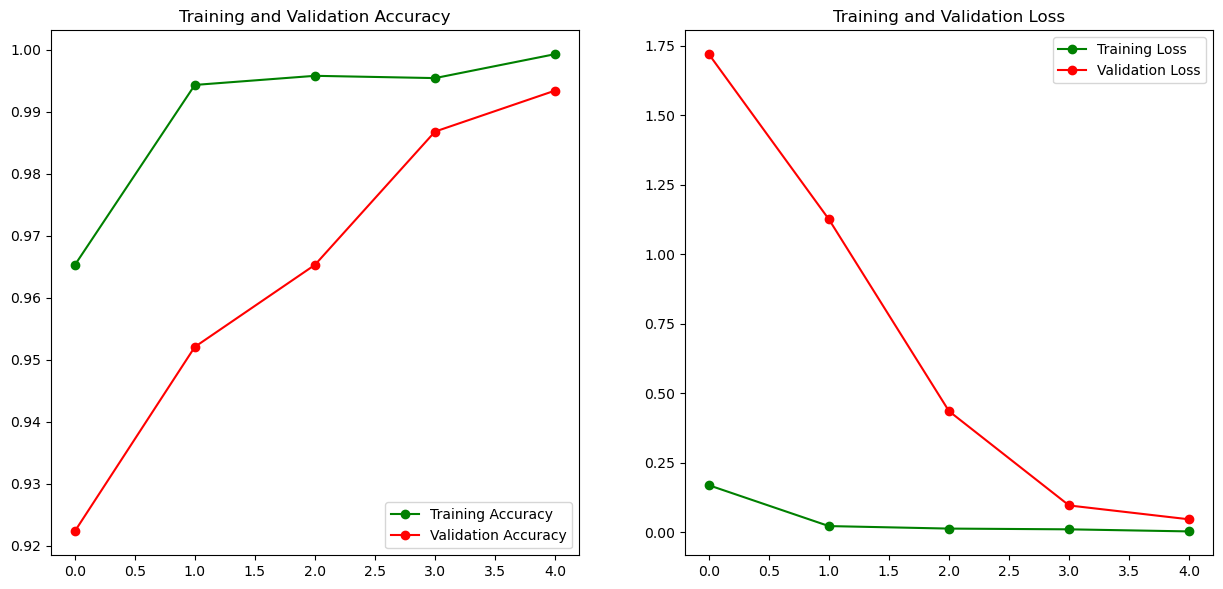

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.plot(epochs_range, acc,"go-", label='Training Accuracy')
plt.plot(epochs_range, val_acc,"ro-", label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 2, 2)
plt.plot(epochs_range, loss,"go-", label='Training Loss')
plt.plot(epochs_range, val_loss,"ro-", label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [44]:
#Classification Report
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(Y_test, y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 41s 812ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       750
           1       0.99      0.99      0.99       761

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



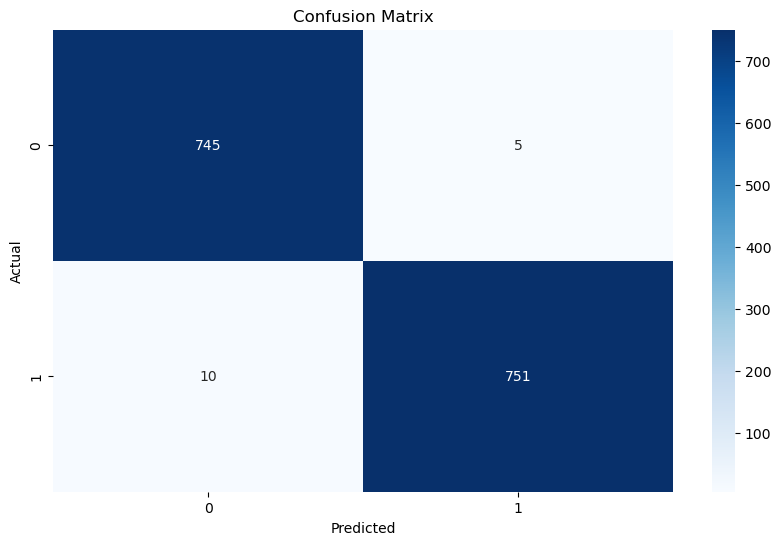

In [45]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
#plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

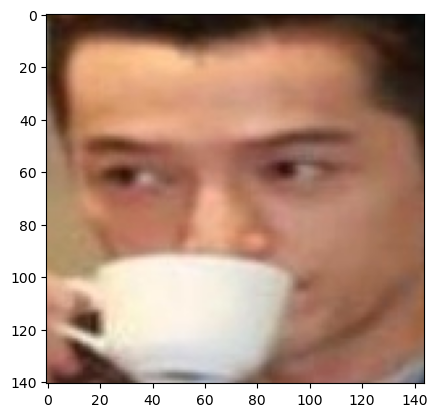

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
[[9.9988323e-01 2.1623746e-04]]
0
The person in the image is not wearing a mask


In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Assuming model is loaded somewhere before this code snippet

input_image_path = 'archive (13)/data/without_mask/without_mask_1002.jpg'
input_image = cv2.imread(input_image_path)

# plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
# plt.show()

plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
plt.show()

input_image_resized = cv2.resize(input_image, (128, 128))

input_image_scaled = input_image_resized / 255  # Assuming model requires normalized input

input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')
